## Advanced EDA: Multi-Graph Comparisons

This section compares both tasks (`stenosis` and `syntax`) across `train`, `val`, and `test`.

You will get:
- Images and annotations count comparisons
- Annotations-per-image distribution comparisons
- Category count comparisons
- Polygon complexity comparisons

In [12]:
# --- COCO helpers and paths ---
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def resolve_project_root() -> Path:
    # Find the nearest parent that contains the data directory.
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / 'data').exists():
            return candidate
        if (candidate / 'archive' / 'data').exists():
            return candidate / 'archive'
    return here

project_root = resolve_project_root()

def get_split_paths(root: Path, ds_name: str, split: str):
    img_dir = root / 'data' / ds_name / split / 'images'
    ann_path = root / 'data' / ds_name / split / 'annotations' / f'{split}.json'
    return img_dir, ann_path

def load_coco_json(json_path: Path):
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def build_image_lookup(coco_data):
    image_lookup = {}
    for item in coco_data['images']:
        image_lookup[item['id']] = item['file_name']
    return image_lookup

def build_annotations_lookup(coco_data):
    anns_lookup = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        anns_lookup.setdefault(img_id, []).append(ann)
    return anns_lookup

,task,split,images,annotations,categories,mean_annotations_per_labeled_image,median_annotations_per_labeled_image
2,stenosis,test,300,386,26,1.286667,1.0
0,stenosis,train,1000,1625,26,1.629890,1.0
1,stenosis,val,200,406,26,2.030000,2.0
5,syntax,test,300,1672,26,5.573333,5.0
3,syntax,train,1000,4976,26,4.976000,5.0
4,syntax,val,200,1168,26,5.840000,6.0


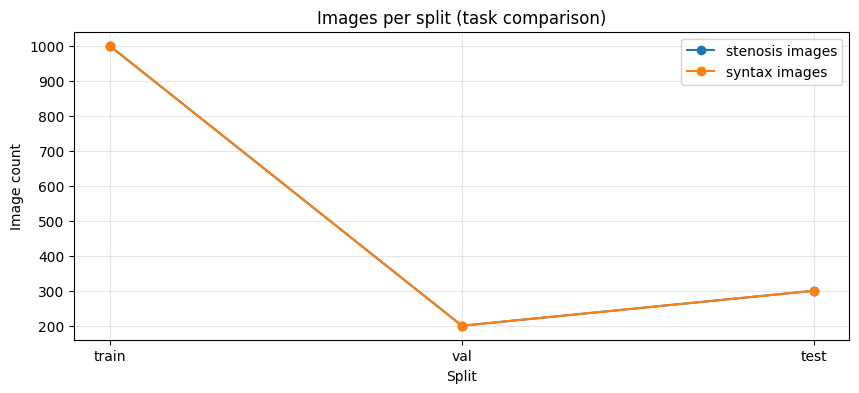

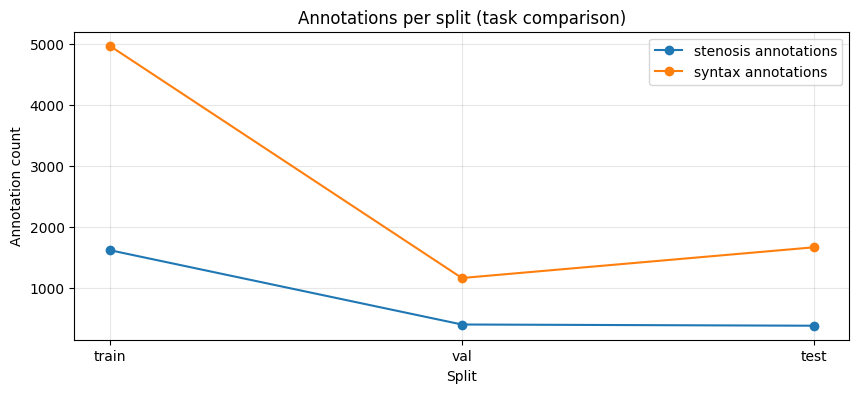

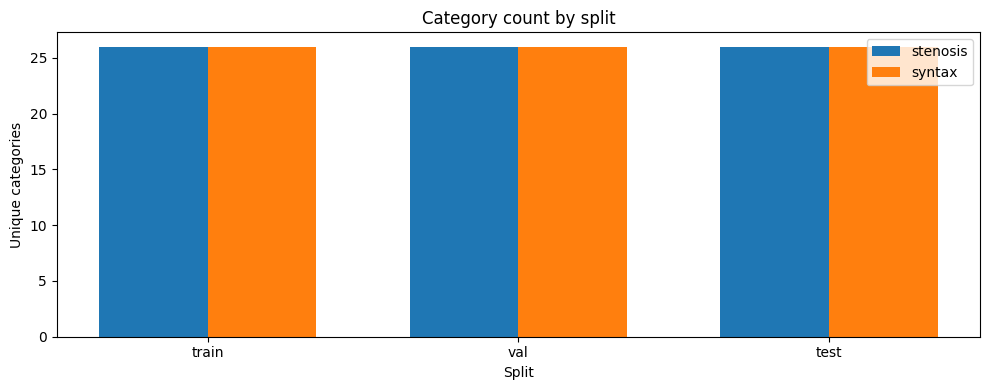

In [13]:
def load_task_split(task_name, split_name):
    img_dir, ann_path = get_split_paths(project_root, task_name, split_name)
    coco = load_coco_json(ann_path)
    return {
        'task': task_name,
        'split': split_name,
        'img_dir': img_dir,
        'coco': coco,
        'image_lookup': build_image_lookup(coco),
        'anns_lookup': build_annotations_lookup(coco)
    }


all_tasks = ['stenosis', 'syntax']
all_splits = ['train', 'val', 'test']
all_data = [load_task_split(task, split) for task in all_tasks for split in all_splits]

# Build split-level summary table
summary_rows = []
for item in all_data:
    coco = item['coco']
    anns_per_image = {}
    for ann in coco['annotations']:
        image_id = ann['image_id']
        anns_per_image[image_id] = anns_per_image.get(image_id, 0) + 1

    ann_counts = list(anns_per_image.values())
    mean_anns = float(np.mean(ann_counts)) if len(ann_counts) > 0 else 0.0
    median_anns = float(np.median(ann_counts)) if len(ann_counts) > 0 else 0.0

    summary_rows.append({
        'task': item['task'],
        'split': item['split'],
        'images': len(coco['images']),
        'annotations': len(coco['annotations']),
        'categories': len(coco['categories']),
        'mean_annotations_per_labeled_image': mean_anns,
        'median_annotations_per_labeled_image': median_anns
    })

adv_summary_df = pd.DataFrame(summary_rows)
display(adv_summary_df.sort_values(['task', 'split']))

# Plot 1: image count comparison
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['images'], marker='o', label=f'{task} images')
plt.title('Images per split (task comparison)')
plt.xlabel('Split')
plt.ylabel('Image count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 2: annotation count comparison
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['annotations'], marker='o', label=f'{task} annotations')
plt.title('Annotations per split (task comparison)')
plt.xlabel('Split')
plt.ylabel('Annotation count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 3: category count comparison
plt.figure(figsize=(10, 4))
x = np.arange(len(all_splits))
width = 0.35
stenosis_cat = adv_summary_df[adv_summary_df['task'] == 'stenosis'].set_index('split').reindex(all_splits)['categories'].values
syntax_cat = adv_summary_df[adv_summary_df['task'] == 'syntax'].set_index('split').reindex(all_splits)['categories'].values

plt.bar(x - width/2, stenosis_cat, width, label='stenosis')
plt.bar(x + width/2, syntax_cat, width, label='syntax')
plt.xticks(x, all_splits)
plt.title('Category count by split')
plt.xlabel('Split')
plt.ylabel('Unique categories')
plt.legend()
plt.tight_layout()
plt.show()

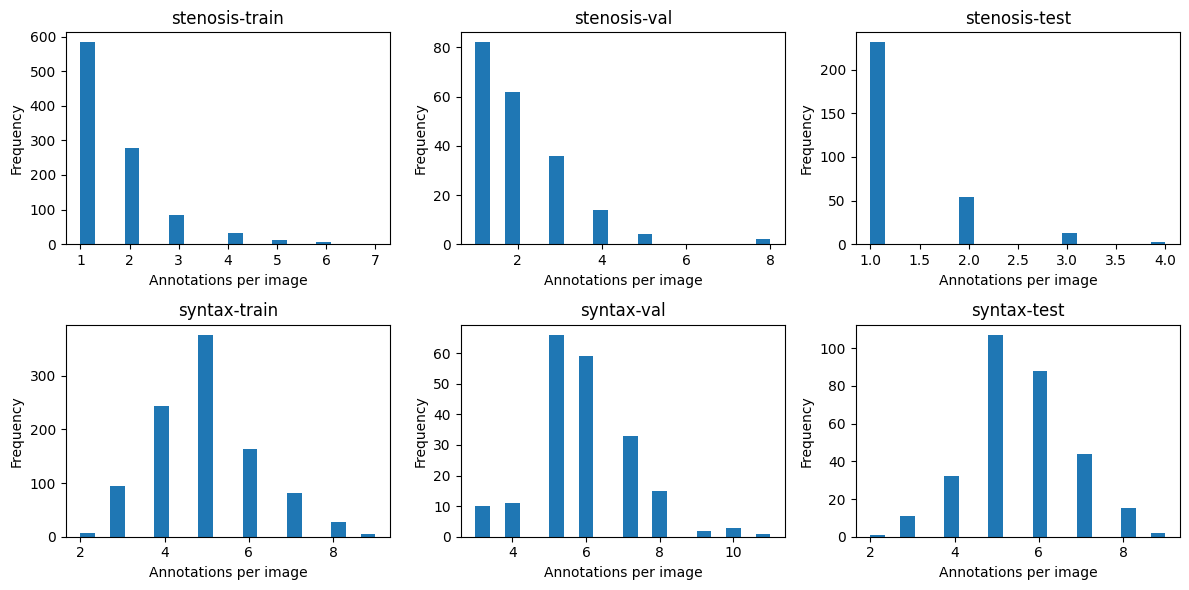

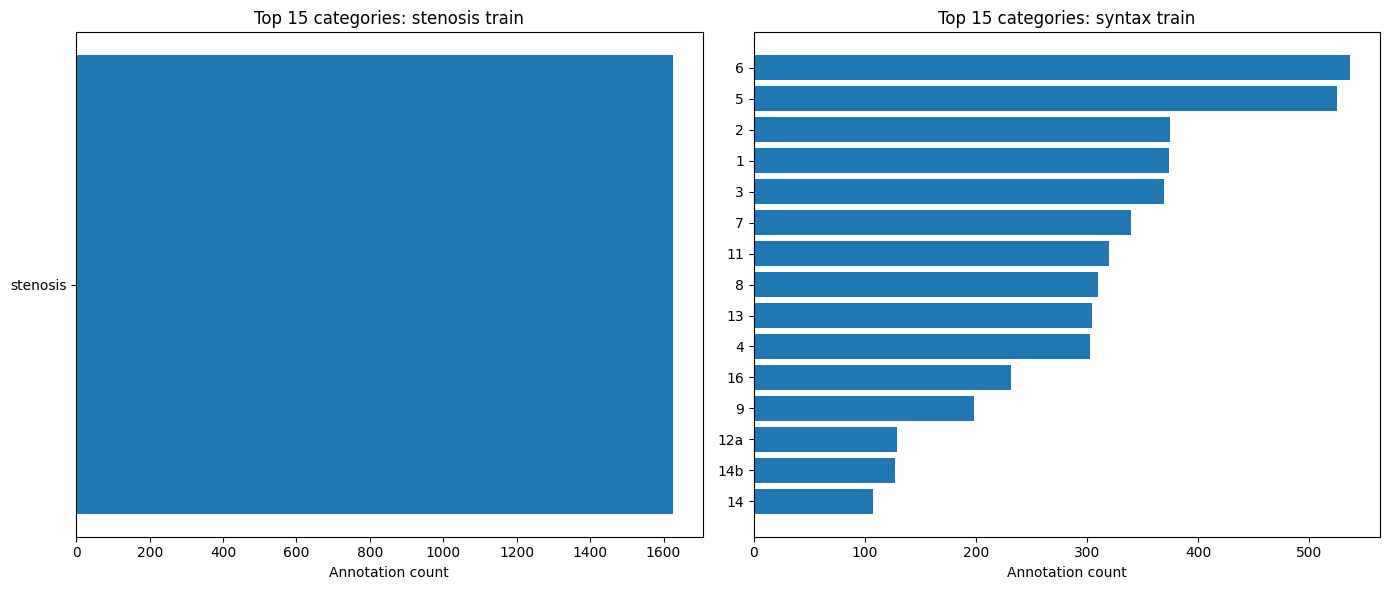

In [14]:
# Plot 4: annotations per image distribution by task and split
plt.figure(figsize=(12, 6))
plot_idx = 1
for task in all_tasks:
    for split in all_splits:
        item = next(x for x in all_data if x['task'] == task and x['split'] == split)
        coco = item['coco']

        anns_per_image = {}
        for ann in coco['annotations']:
            image_id = ann['image_id']
            anns_per_image[image_id] = anns_per_image.get(image_id, 0) + 1

        values = list(anns_per_image.values())
        if len(values) == 0:
            values = [0]

        plt.subplot(2, 3, plot_idx)
        plt.hist(values, bins=20)
        plt.title(f'{task}-{split}')
        plt.xlabel('Annotations per image')
        plt.ylabel('Frequency')
        plot_idx += 1

plt.tight_layout()
plt.show()

# Plot 5: top categories in train split (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

for ax, task in zip(axes, all_tasks):
    item = next(x for x in all_data if x['task'] == task and x['split'] == 'train')
    coco = item['coco']
    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}

    cat_counts = {}
    for ann in coco['annotations']:
        cid = ann['category_id']
        cat_counts[cid] = cat_counts.get(cid, 0) + 1

    df = pd.DataFrame([
        {'category': cat_id_to_name.get(cid, str(cid)), 'count': cnt}
        for cid, cnt in cat_counts.items()
    ]).sort_values('count', ascending=False).head(15)

    ax.barh(df['category'].astype(str), df['count'])
    ax.invert_yaxis()
    ax.set_title(f'Top 15 categories: {task} train')
    ax.set_xlabel('Annotation count')

plt.tight_layout()
plt.show()

,task,split,mean_points,median_points,p90_points
2,stenosis,test,19.430052,17.0,32.5
0,stenosis,train,23.857846,18.0,46.0
1,stenosis,val,20.369458,17.0,31.0
5,syntax,test,91.656699,71.0,174.0
3,syntax,train,83.072146,61.5,176.0
4,syntax,val,79.702055,61.0,164.0


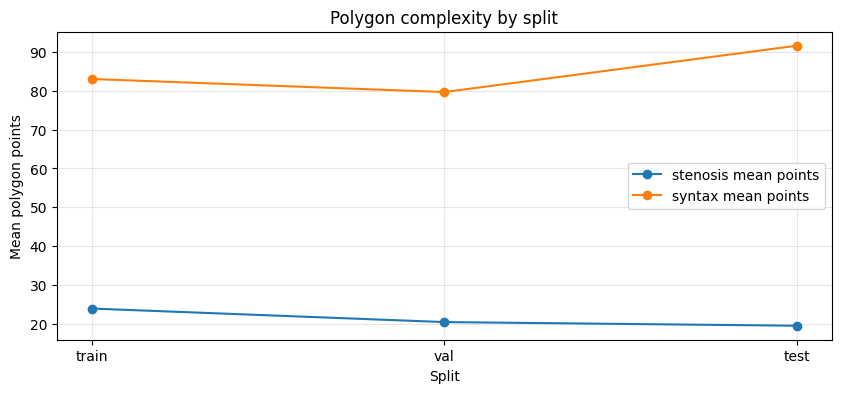

NameError: name 'cv2' is not defined

In [15]:
# Plot 6: polygon complexity comparison (number of points per polygon)
complexity_rows = []

for item in all_data:
    task = item['task']
    split = item['split']
    coco = item['coco']

    point_counts = []
    for ann in coco['annotations']:
        seg = ann.get('segmentation', [])
        if not isinstance(seg, list):
            continue
        for poly in seg:
            n_points = len(poly) // 2
            if n_points > 0:
                point_counts.append(n_points)

    if len(point_counts) == 0:
        point_counts = [0]

    complexity_rows.append({
        'task': task,
        'split': split,
        'mean_points': float(np.mean(point_counts)),
        'median_points': float(np.median(point_counts)),
        'p90_points': float(np.percentile(point_counts, 90))
    })

complexity_df = pd.DataFrame(complexity_rows)
display(complexity_df.sort_values(['task', 'split']))

plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = complexity_df[complexity_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['mean_points'], marker='o', label=f'{task} mean points')
plt.title('Polygon complexity by split')
plt.xlabel('Split')
plt.ylabel('Mean polygon points')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 7: sampled image intensity histograms (task-level)
def sample_intensities(task_name, max_images=120):
    item = next(x for x in all_data if x['task'] == task_name and x['split'] == 'train')
    img_dir = item['img_dir']
    images = item['coco']['images']

    sample = images if len(images) <= max_images else random.sample(images, max_images)
    pixels = []

    for im in sample:
        arr = cv2.imread(str(img_dir / im['file_name']), cv2.IMREAD_GRAYSCALE)
        if arr is not None:
            pixels.append(arr.flatten())

    if len(pixels) == 0:
        return np.array([0], dtype=np.uint8)

    return np.concatenate(pixels)

stenosis_pixels = sample_intensities('stenosis')
syntax_pixels = sample_intensities('syntax')

plt.figure(figsize=(10, 4))
plt.hist(stenosis_pixels, bins=50, alpha=0.6, density=True, label='stenosis train')
plt.hist(syntax_pixels, bins=50, alpha=0.6, density=True, label='syntax train')
plt.title('Pixel intensity comparison (sampled train images)')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.legend()
plt.show()

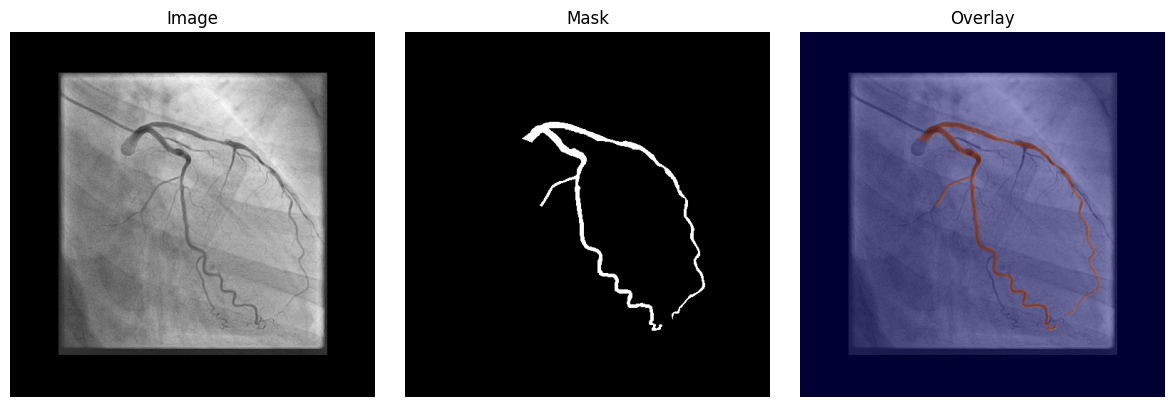

In [ ]:
def polygons_to_mask(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for ann in annotations:
        seg = ann.get('segmentation', [])
        if not isinstance(seg, list):
            continue
        for poly in seg:
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
            pts = np.round(pts).astype(np.int32)
            if pts.shape[0] >= 3:
                cv2.fillPoly(mask, [pts], 1)
    return mask


def show_random_overlay(split='train'):
    split_info = data_info[split]
    coco = split_info['coco']
    image_lookup = split_info['image_lookup']
    anns_lookup = split_info['anns_lookup']
    img_dir = split_info['img_dir']

    img_item = random.choice(coco['images'])
    img_id = img_item['id']
    file_name = image_lookup[img_id]

    image = cv2.imread(str(img_dir / file_name), cv2.IMREAD_GRAYSCALE)
    anns = anns_lookup.get(img_id, [])
    mask = polygons_to_mask(anns, image.shape[0], image.shape[1])

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.4)
    plt.title('Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


show_random_overlay('train')

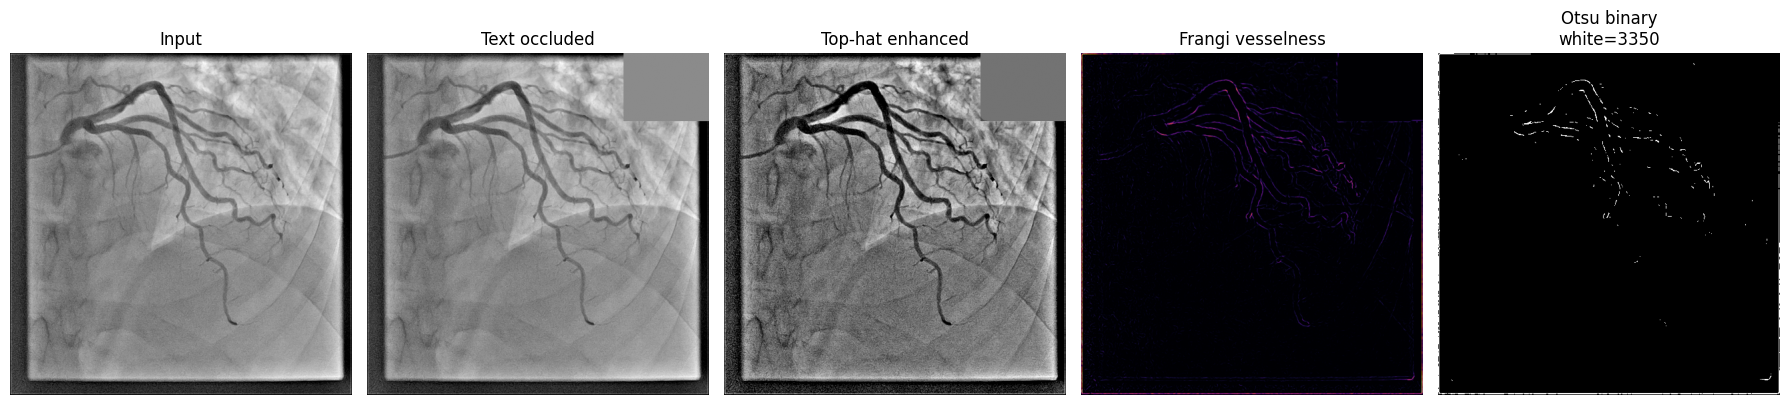

Demo image: 293.png


In [ ]:
# --- Imports ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import Any, Dict, List, Sequence, Tuple

from skimage.filters import frangi, threshold_otsu


# --- Multi-scale Top-hat Enhancement ---
def multiscale_tophat_enhance(
    image: np.ndarray,
    radii: Sequence[int] = (10,),
) -> np.ndarray:
    """Contrast enhancement using white and black top-hat transforms."""
    
    image_u8 = image.astype(np.uint8)
    white_maps = []
    black_maps = []

    for r in radii:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
        white = cv2.morphologyEx(image_u8, cv2.MORPH_TOPHAT, k)
        black = cv2.morphologyEx(image_u8, cv2.MORPH_BLACKHAT, k)
        white_maps.append(white.astype(np.float32))
        black_maps.append(black.astype(np.float32))

    white_map = np.max(np.stack(white_maps, axis=0), axis=0)
    black_map = np.max(np.stack(black_maps, axis=0), axis=0)

    enhanced = image_u8.astype(np.float32) + white_map - black_map
    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

    return enhanced


# --- Frangi Vesselness ---
def frangi_vesselness(
    image: np.ndarray,
    sigmas: Sequence[float] = (1.0, 2.0, 3.0, 4.0),
    black_ridges: bool = False,
) -> np.ndarray:
    """Apply Frangi vesselness filter and normalize to [0, 1]."""

    norm = image.astype(np.float32) / 255.0
    vessel = frangi(norm, sigmas=sigmas, black_ridges=black_ridges)

    vessel = np.nan_to_num(vessel, nan=0.0, posinf=0.0, neginf=0.0)

    if vessel.max() > 0:
        vessel = vessel / vessel.max()

    return vessel.astype(np.float32)


# --- Otsu Threshold ---
def otsu_binary(vessel_map: np.ndarray) -> np.ndarray:
    """Binarize vesselness map using Otsu thresholding."""

    if np.allclose(vessel_map, vessel_map.flat[0]):
        return np.zeros_like(vessel_map, dtype=np.uint8)

    th = threshold_otsu(vessel_map)
    return (vessel_map >= th).astype(np.uint8)


# --- Preprocessing (NO OCCLUSION REMOVAL) ---
def preprocess_single_frame(
    image: np.ndarray,
    tophat_radii: Sequence[int] = (10,),
    frangi_sigmas: Sequence[float] = (1.0, 2.0, 3.0, 4.0),
) -> Dict[str, Any]:
    """
    Complete preprocessing:
    Grayscale → Top-hat → Frangi → Otsu
    """

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 🔥 No occlusion removal — direct use
    masked = image

    enhanced = multiscale_tophat_enhance(masked, radii=tophat_radii)
    vessel_map = frangi_vesselness(enhanced, sigmas=frangi_sigmas)
    binary = otsu_binary(vessel_map)

    white_count = int(binary.sum())

    return {
        "input": image,
        "masked": masked,
        "enhanced": enhanced,
        "vessel_map": vessel_map,
        "binary": binary,
        "white_count": white_count,
    }


# --- Key Frame Detection ---
def detect_key_frame(
    clip_frames: List[np.ndarray],
    middle_start_ratio: float = 0.15,
    middle_end_ratio: float = 0.85,
    tophat_radii: Sequence[int] = (10,),
    frangi_sigmas: Sequence[float] = (1.0, 2.0, 3.0, 4.0),
) -> Tuple[int, List[int]]:
    """
    Detect key frame using vessel pixel count.
    """

    if len(clip_frames) == 0:
        raise ValueError("clip_frames is empty")

    scores = []

    for frame in clip_frames:
        out = preprocess_single_frame(
            frame,
            tophat_radii=tophat_radii,
            frangi_sigmas=frangi_sigmas,
        )
        scores.append(out["white_count"])

    n = len(scores)

    start = max(1, int(n * middle_start_ratio))
    end = min(n - 2, int(n * middle_end_ratio))

    local_maxima = []

    for i in range(start, end + 1):
        if scores[i] > scores[i - 1] and scores[i] > scores[i + 1]:
            local_maxima.append(i)

    if local_maxima:
        best_idx = max(local_maxima, key=lambda idx: scores[idx])
    else:
        best_idx = int(np.argmax(scores[start:end + 1])) + start

    return best_idx, scores


# --- Demo on One Image ---
train_item = data_info['train']

demo_image_info = random.choice(train_item['coco']['images'])
demo_path = train_item['img_dir'] / demo_image_info['file_name']

demo_img = cv2.imread(str(demo_path), cv2.IMREAD_GRAYSCALE)

if demo_img is None:
    raise FileNotFoundError(f"Could not read image: {demo_path}")

prep = preprocess_single_frame(demo_img)


# --- Visualization ---
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(prep['input'], cmap='gray')
axes[0].set_title('Input')

axes[1].imshow(prep['masked'], cmap='gray')
axes[1].set_title('Masked (same as input)')

axes[2].imshow(prep['enhanced'], cmap='gray')
axes[2].set_title('Top-hat enhanced')

axes[3].imshow(prep['vessel_map'], cmap='inferno')
axes[3].set_title('Frangi vesselness')

axes[4].imshow(prep['binary'], cmap='gray')
axes[4].set_title(f"Otsu binary\nwhite={prep['white_count']}")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Demo image:', demo_path.name)

In [ ]:
# --- Binary classification model setup: ResNet50 / Inception-v3 + optional CBAM ---
import torch.nn.functional as F
from torchvision import models


class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):
    def __init__(self, channels: int, reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction=reduction)
        self.spatial_attention = SpatialAttention(kernel_size=spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x


class BinaryClassifier(nn.Module):
    def __init__(self, backbone: str = 'resnet50', use_cbam: bool = True, pretrained: bool = False):
        super().__init__()
        backbone = backbone.lower()
        self.backbone_name = backbone
        self.use_cbam = use_cbam
        self.activation = nn.Sigmoid()

        if backbone == 'resnet50':
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            base = models.resnet50(weights=weights)
            feature_dim = base.fc.in_features
            self.features = nn.Sequential(*list(base.children())[:-2])
            self.cbam = CBAM(feature_dim) if use_cbam else nn.Identity()
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Linear(feature_dim, 1)

        elif backbone in ('inception_v3', 'inception-v3', 'inception'):
            weights = models.Inception_V3_Weights.DEFAULT if pretrained else None
            self.backbone = models.inception_v3(weights=weights, aux_logits=False)
            feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.cbam = nn.Identity()
            self.classifier = nn.Linear(feature_dim, 1)

        else:
            raise ValueError("backbone must be 'resnet50' or 'inception_v3'")

    def forward(self, x):
        if self.backbone_name == 'resnet50':
            x = self.features(x)
            x = self.cbam(x)
            x = self.pool(x).flatten(1)
            logits = self.classifier(x)
            return self.activation(logits).squeeze(1)

        x = self.backbone(x)
        logits = self.classifier(x)
        return self.activation(logits).squeeze(1)


if 'backbone_name' not in globals():
    backbone_name = 'resnet50'
if 'use_cbam' not in globals():
    use_cbam = True


def build_model(backbone: str = backbone_name, use_cbam_flag: bool = use_cbam, pretrained: bool = False):
    model = BinaryClassifier(backbone=backbone, use_cbam=use_cbam_flag, pretrained=pretrained)
    return model.to(device)


model = build_model(pretrained=False)
print(model)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print('Loss: BCELoss')
print('Optimizer: Adam')
print('Learning rate:', LR)
print('Batch size:', BATCH_SIZE)
print('Epochs:', EPOCHS)

# Model already returns probabilities in [0, 1].
def predict_proba(outputs: torch.Tensor) -> torch.Tensor:
    return outputs


class BinaryImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = cv2.imread(str(self.image_paths[index]), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(self.image_paths[index])
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))
        x = torch.tensor(image, dtype=torch.float32)
        y = torch.tensor(self.labels[index], dtype=torch.float32)
        return x, y


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / max(len(loader.dataset), 1)


def validate_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * images.size(0)
    return total_loss / max(len(loader.dataset), 1)

BinaryClassifier(
  (activation): Sigmoid()
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
# --- Test evaluation ---
def collect_binary_labels(coco_data):
    image_labels = {}
    for image in coco_data['images']:
        image_labels[image['id']] = 0

    for ann in coco_data['annotations']:
        image_labels[ann['image_id']] = 1

    return image_labels


def build_image_paths_and_labels(split_name: str):
    split_info = data_info[split_name]
    coco = split_info['coco']
    image_lookup = split_info['image_lookup']
    img_dir = split_info['img_dir']
    image_labels = collect_binary_labels(coco)

    image_paths = []
    labels = []
    for image in coco['images']:
        image_paths.append(img_dir / image_lookup[image['id']])
        labels.append(float(image_labels[image['id']]))

    return image_paths, labels


test_paths, test_labels = build_image_paths_and_labels('test')
test_dataset = BinaryImageDataset(test_paths, test_labels)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model.eval()
test_loss = 0.0
all_probs = []
all_targets = []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = targets.to(device)
        outputs = model(images)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * images.size(0)
        all_probs.extend(outputs.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

test_loss = test_loss / max(len(test_loader.dataset), 1)
test_preds = [1 if prob >= 0.5 else 0 for prob in all_probs]
test_targets = [int(t) for t in all_targets]

tp = sum(1 for p, t in zip(test_preds, test_targets) if p == 1 and t == 1)
tn = sum(1 for p, t in zip(test_preds, test_targets) if p == 0 and t == 0)
fp = sum(1 for p, t in zip(test_preds, test_targets) if p == 1 and t == 0)
fn = sum(1 for p, t in zip(test_preds, test_targets) if p == 0 and t == 1)

accuracy = (tp + tn) / max(len(test_targets), 1)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = (2 * precision * recall) / max(precision + recall, 1e-9)

print('Test results')
print('  loss:', round(test_loss, 4))
print('  accuracy:', round(accuracy, 4))
print('  precision:', round(precision, 4))
print('  recall:', round(recall, 4))
print('  f1:', round(f1, 4))
print('  confusion_matrix:')
print('    TP:', tp, 'FP:', fp)
print('    FN:', fn, 'TN:', tn)


Test results
  loss: 0.6102
  accuracy: 0.79
  precision: 1.0
  recall: 0.79
  f1: 0.8827
  confusion_matrix:
    TP: 237 FP: 0
    FN: 63 TN: 0
